# Online Payment Fraud Detection Analysis
Goal: Develop a high accuracy classification model to detect fraudulent transactions whithin a dataset of 6.3 million records

In [1]:
#Load reguired libraries
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator
import time

In [2]:
#Load dataset in dataframe
path = os.path.join("..", "data","onlinefraud.csv")
df = pd.read_csv(path)

### <u>Exploratory Data Analysis: Transaction Distribution</u>
Analysis of the transaction distribution reveals a significant overlap between fraudulent and legitimate activity on the lower end of the scale below 10M. The data indicates that fraudulent transactions are heavily concentrated in lower value ranges, suggesting that high volume, low value testing patterns are a primary indicator of risk in this dataset. Fraudulent cases represent less than 0.1% of the total volume, requiring a specialized approach in this case a Stratified Splitting used in the model to ensure the minority class is properly identified.

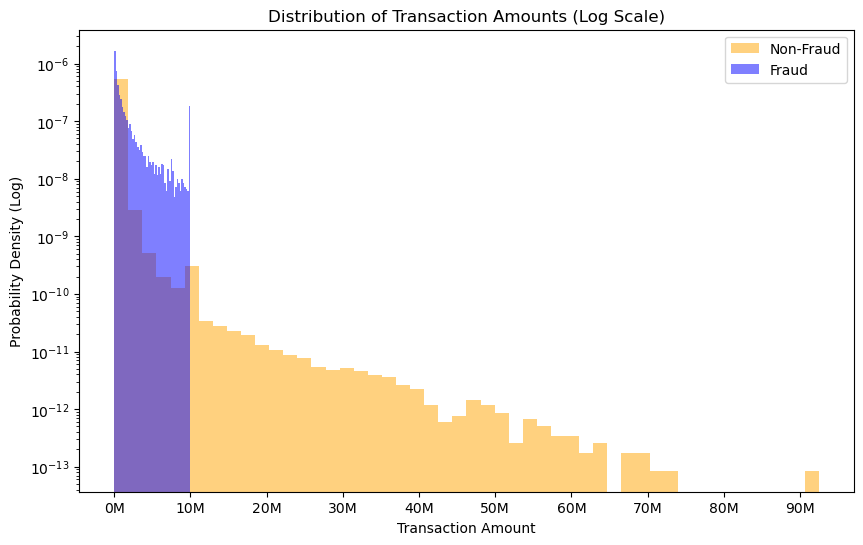

In [9]:
#Plot histogram for Fraud vs Non-Fraud to find correlation
def thousands(x, pos):
    return f'{x*1e-6:,.0f}M'

formatter = FuncFormatter(thousands)

fraud = df[df["isFraud"] == 1]
non_fraud = df[df["isFraud"] == 0]
plt.figure(figsize=(10, 6))

# This tells Matplotlib to place a tick every 10,000,000 units (10,000K)
plt.gca().xaxis.set_major_locator(MultipleLocator(10000000))

# Apply your formatter after setting the locator
plt.gca().xaxis.set_major_formatter(formatter)
plt.hist(non_fraud["amount"], bins=50, alpha=0.5, label='Non-Fraud', color='orange', density=True)
plt.hist(fraud["amount"], bins=50, alpha=0.5, label='Fraud', color='blue', density=True)

plt.yscale("log") 
plt.legend(loc='upper right')
plt.title('Distribution of Transaction Amounts (Log Scale)')
plt.xlabel("Transaction Amount")
plt.ylabel("Probability Density (Log)")
#plt.xscale("log")
plt.gca().xaxis.set_major_formatter(formatter)
plt.show()

### <u>Exploratory Data Analysis: Baseline Logistic Regression Performance</u>
After training the baseline Logistic Regression model, the execution time for training and prediction on 1.2M test records was approximately 23.74 seconds.
<u>Performance Summary</u>:
* Detection Rate: Out of 1,643 actual fraud cases, the model successfully identified 828 but failed to catch 815.
* Recall & Reliability: With a recall of 0.50, the model is essentially a coin flip for detecting fraud missing nearly 50% of suspicious activity.
* False Alarms: There were 495 false positives, where legitimate customers were incorrectly flagged as fraudulent.
<u>Key Drivers of Fraud Linear Influence</u>:\
The model identified the following top 5 features as the strongest linear indicators of fraud:

1. oldbalanceOrg: The balance in the originating account before the transaction.

2. type_CASH_OUT: Whether the user attempted to withdraw the funds immediately.

3. newbalanceOrig: The remaining balance in the origin account.

4. type_TRANSFER: Transactions involving direct transfers between accounts.

5. type_PAYMENT: Standard payment transactions.

Model Training and Prediction took: 23.37 seconds
Confusion Matrix (Threshold 0.1):
[[1270386     495]
 [    815     828]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.63      0.50      0.56      1643

    accuracy                           1.00   1272524
   macro avg       0.81      0.75      0.78   1272524
weighted avg       1.00      1.00      1.00   1272524



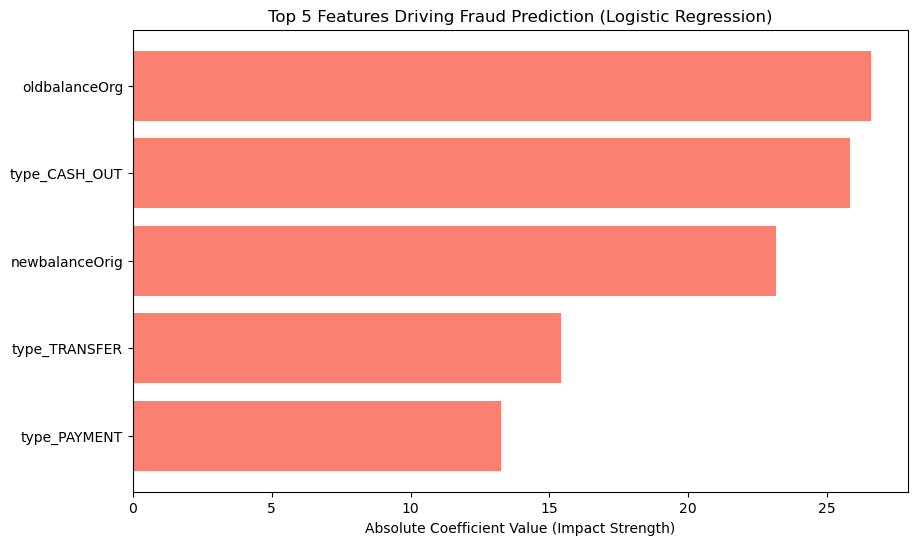

In [10]:
#Start the timer
start_time = time.time()
#Encode data string values to numeric
df_encoded = pd.get_dummies(df, columns=['type'], drop_first=True)
#Split data between training and testing. Use stratify to make splitting more accurate to include fraud case in both testing and training
X = df_encoded.drop(['isFraud','isFlaggedFraud','nameOrig','nameDest'],axis=1)
Y = df_encoded['isFraud']
Xtrain,Xtest,Ytrain,Ytest = train_test_split(
    X,Y,test_size =0.2, random_state=42,stratify=Y
)

#Train linear regression model
scaler = StandardScaler()

Xtrain = scaler.fit_transform(Xtrain)
Xtest = scaler.transform(Xtest)
model = LogisticRegression(max_iter=1000)
model.fit(Xtrain, Ytrain)
Ypredict = model.predict(Xtest)
#End the timer
end_time = time.time()

# Instead of 0.5, let's try a 0.1 threshold to see if we can detect more fraudulent cases and print Confusion Matrix and Classification Report
Y_prob = model.predict_proba(Xtest)[:, 1]
Y_predict_low_threshold = (Y_prob > 0.1).astype(int)

execution_time = end_time - start_time
print(f"Model Training and Prediction took: {execution_time:.2f} seconds")

print("Confusion Matrix (Threshold 0.1):")
print(confusion_matrix(Ytest, Y_predict_low_threshold))

print("\nClassification Report:")
print(classification_report(Ytest, Y_predict_low_threshold))
#Displaying linear regression top 5 features driving the fraud prediction model
coefficients = model.coef_[0]
feature_names = X.columns

importance_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
importance_df['Abs_Importance'] = importance_df['Coefficient'].abs()
importance_df = importance_df.sort_values(by='Abs_Importance', ascending=False)

# Visualize Logistic Regression Feature Importance
plt.figure(figsize=(10, 6))
# We use Abs_Importance to show the "strength" of the signal
plt.barh(importance_df['Feature'][:5], importance_df['Abs_Importance'][:5], color='salmon')

plt.xlabel('Absolute Coefficient Value (Impact Strength)')
plt.title('Top 5 Features Driving Fraud Prediction (Logistic Regression)')
plt.gca().invert_yaxis() # Highest importance at the top
plt.show()

### <u>Exploratory Data Analysis: Classification Performance</u>
After training the classification model, the execution time for training and prediction on 1.2M test records was approximately 5 minutes and 36.46 seconds.
<u>Performance Summary</u>:
* Detection Success: The model successfully identified 1,207 fraud cases, significantly outperforming the baseline.
* Recall & Reliability: With a recall of 0.73, the model captures nearly 3 out of every 4 fraudulent transactions.
* False Alarm Reduction: Most importantly, false positives dropped from 495 to just 8. This represents a near-perfect precision of 0.99, meaning the model almost never interrupts a legitimate customer.
<u>Key Drivers of Fraud Linear Influence</u>:\
The model identified the following top 5 features as the strongest linear indicators of fraud:
1. newbalanceDest: The new balance of recipient after the transaction.
    
2. oldbalanceOrg: The balance in the originating account before the transaction.

3. amount: The amount of the transaction.

4. step: Represents a unit of time where 1 step equals 1 hour.

5. type_TRANSFER: Transactions involving direct transfers between accounts.

Model Training and Prediction took: 5 minute(s) and 39.10 seconds
--- Random Forest Results ---
Confusion Matrix:
[[1270873       8]
 [    436    1207]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.99      0.73      0.84      1643

    accuracy                           1.00   1272524
   macro avg       1.00      0.87      0.92   1272524
weighted avg       1.00      1.00      1.00   1272524



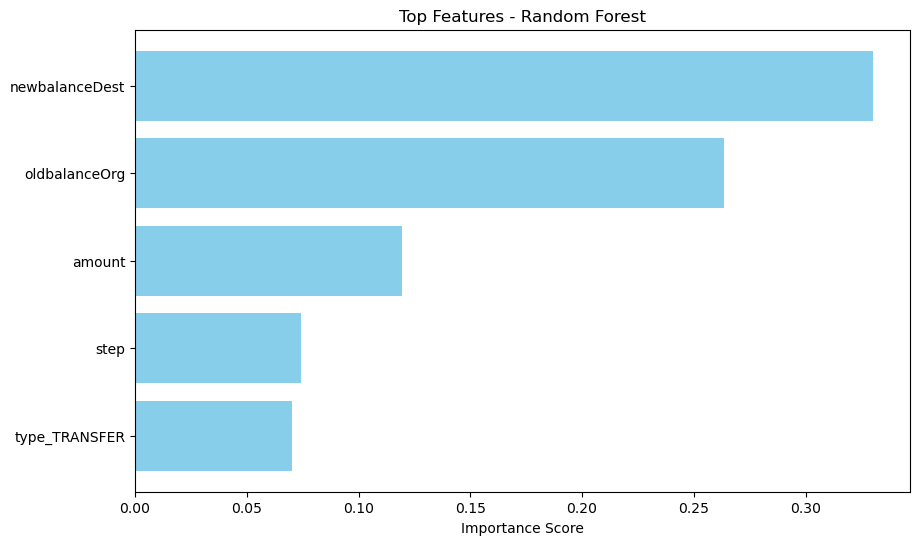

In [11]:
#Start the timer
start_time = time.time()
#Use random forest classifier to see if we can get more accurate prediction
classifier = RandomForestClassifier(n_estimators=100, random_state=42,n_jobs=-1,max_depth=10)
classifier.fit(Xtrain, Ytrain)
y_pred = classifier.predict(Xtest)
#End the timer
end_time = time.time()
execution_time = end_time - start_time
# Calculate minutes and remaining seconds
minutes, seconds = divmod(execution_time, 60)

if minutes > 0:
    print(f"Model Training and Prediction took: {int(minutes)} minute(s) and {seconds:.2f} seconds")
else:
    print(f"Model Training and Prediction took: {seconds:.2f} seconds")
#Output rando forest classification Confusion matrix and Classification report
print("--- Random Forest Results ---")
print("Confusion Matrix:")
print(confusion_matrix(Ytest, y_pred))

# 2. See the Precision, Recall, and F1-Score
print("\nClassification Report:")
print(classification_report(Ytest, y_pred))
# Get feature importances from the Random Forest
importances = classifier.feature_importances_
feature_names = X.columns
rf_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
rf_importance_df = rf_importance_df.sort_values(by='Importance', ascending=False)

# Visualize it
plt.figure(figsize=(10, 6))
plt.barh(rf_importance_df['Feature'][:5], rf_importance_df['Importance'][:5], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Top Features - Random Forest')
plt.gca().invert_yaxis()
plt.show()

### <u>Conclusion</u>
While the Random Forest Classifier was more computationally expensive than the baseline increasing processing time by approximately 13x the performance gains are substantial. The model improved fraud detection Recall from a baseline of 50% to 73%. Furthermore, the classifier significantly enhanced the user experience by reducing False Positives from 495 down to only 8 cases, ensuring legitimate transactions are rarely interrupted. 
